# Домашнее задание 1. Autoencoders & Frechet Inception Distance


В этом домашнем задании вам предлагается вспомнить то, что происходило на семинарах 1-2, написать свой автоэнкодер на CIFAR10 и использовать эмбеддинги от этого автоэнкодера чтобы посчитать Frechet Inception Distance (FID) между разными классами в CIFAR10

In [1]:
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Subset
import matplotlib.pyplot as plt
from tqdm.auto import tqdm, trange
from sklearn.ensemble import GradientBoostingClassifier
from collections import defaultdict
import seaborn as sns

Будем использовать torchvision для работы с данными.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    lambda x: (x * 2) - 1
])

In [3]:
train_dataset = datasets.CIFAR10(
    './cifar',
    train=True,
    transform=transform,
    download=True)
val_dataset = datasets.CIFAR10(
    './cifar',
    train=False,
    transform=transform,
    download=True)
len(train_dataset), len(val_dataset)

100%|██████████████████████████████████████████████████████████████| 170498071/170498071 [00:09<00:00, 18631626.36it/s]


Extracting ./cifar\cifar-10-python.tar.gz to ./cifar
Files already downloaded and verified


(50000, 10000)

Раз мы используем нормализацию картинок, то чтобы их нарисовать - надо их обратно разнормализировать

In [4]:
def denormalize_image(image):
    return (image + 1) / 2

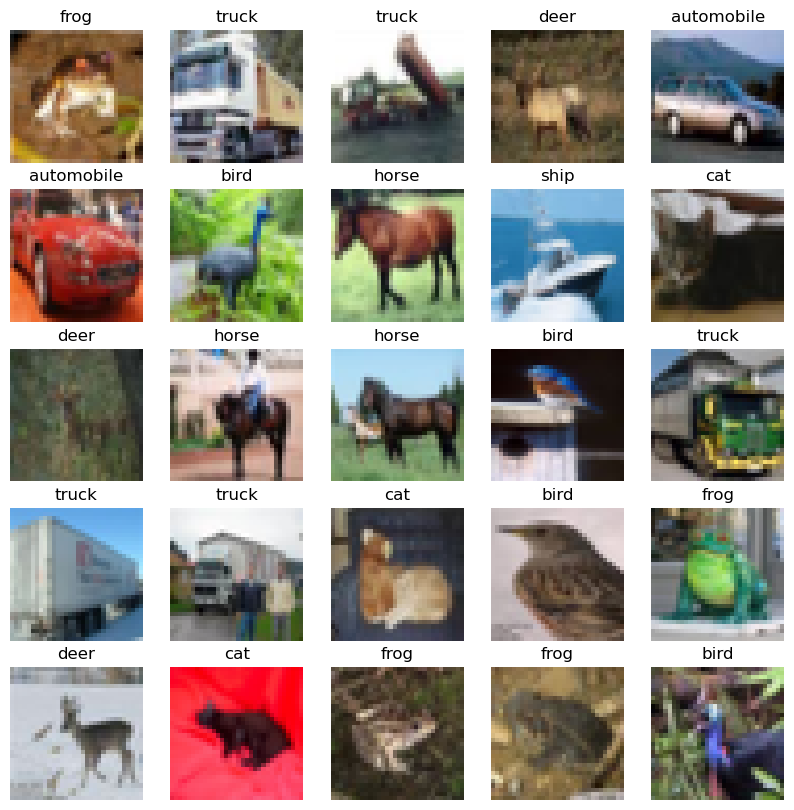

In [5]:
text_labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(10, 10))
for index, (image, label) in enumerate(train_dataset):
    plt.subplot(5, 5, index + 1)
    plt.imshow(denormalize_image(image.permute(1, 2, 0)))
    plt.axis('off')
    plt.title(text_labels[label])
    if index == 24: break
plt.show()

Размерность картинок: 3 канала 32х32 пикселя

In [6]:
image.shape

torch.Size([3, 32, 32])

In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
len(train_loader), len(val_loader)

(1563, 10000)

### Задание 1. Обучить AE (3 балла)

Постройте свой AE, можете использовать любые блоки которые вам кажутся необходимыми.

<img src='https://miro.medium.com/max/1400/1*44eDEuZBEsmG_TCAKRI3Kw@2x.png' width=500>

Напишите классы Encoder и Decoder

хинт: вам пригодятся nn.AvgPool2d/nn.MaxPool2d/Conv2d в энкодере и nn.Upsample/nn.ConvTranspose2d в декодере

In [20]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        ### BEGIN SOLUTION
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        ### END SOLUTION

    def forward(self, x):
        ### BEGIN SOLUTION
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        
        x = F.relu(self.conv3(x))
        x = self.pool3(x)
        return x  
        ### END SOLUTION


In [22]:
encoder = Encoder()
noise = torch.rand(1, 3, 32, 32) - 1
assert encoder(noise).view(-1).numel() < 1*3*32*32

In [23]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        ### BEGIN SOLUTION
        self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.conv1 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        
        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.conv2 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        
        self.up3 = nn.Upsample(scale_factor=2, mode='nearest')
        self.conv3 = nn.Conv2d(16, 3, kernel_size=3, padding=1)
        ### END SOLUTION

    def forward(self, x):
        ### BEGIN SOLUTION
        x = self.up1(x)
        x = F.relu(self.conv1(x))
        
        x = self.up2(x)
        x = F.relu(self.conv2(x))
        
        x = self.up3(x)
        x = torch.sigmoid(self.conv3(x))
        return x
        ### END SOLUTION

In [24]:
decoder = Decoder()
noise = torch.rand(1, 3, 32, 32)
emb = encoder(noise)
assert decoder(emb).shape == (1, 3, 32, 32)

Посчитаем скор классификации картинок по эмбеддингам необученного энкодора, и в конце сравним с обученным. Для ускорения расчета, мы используем только часть трейна.

In [25]:
def classification_score(encoder, _train_dataset, val_dataset, device):
    encoder.eval()
    torch.manual_seed(0)
    train_dataset = Subset(_train_dataset, torch.randperm(len(_train_dataset))[:5000])
    X_train = []
    y_train = []
    for image, label in tqdm(train_dataset):
        image = image.to(device)
        with torch.no_grad():
            emb = encoder(image[None, ...])
        X_train.append(emb.cpu().numpy().reshape(-1))
        y_train.append(label)
    X_train = np.stack(X_train)
    y_train = np.stack(y_train)
    clf = GradientBoostingClassifier(n_estimators=50, max_depth=5, verbose=1, random_state=0)
    clf.fit(X_train, y_train)
    X_val = []
    y_val = []
    for image, label in tqdm(val_dataset):
        image = image.to(device)
        with torch.no_grad():
            emb = encoder(image[None, ...])
        X_val.append(emb.cpu().numpy().reshape(-1))
        y_val.append(label)
    X_val = np.stack(X_val)
    y_val = np.stack(y_val)
    return clf.score(X_val, y_val)

In [26]:
classification_score(Encoder(), train_dataset, val_dataset, 'cpu')

  0%|          | 0/5000 [00:00<?, ?it/s]

      Iter       Train Loss   Remaining Time 
         1           2.0709           13.22m
         2           1.9046           12.95m
         3           1.7721           12.76m
         4           1.6587           12.57m
         5           1.5552           12.37m
         6           1.4693           12.17m
         7           1.3926           11.96m
         8           1.3223           11.71m
         9           1.2573           11.44m
        10           1.2046           11.18m
        20           0.8178            8.42m
        30           0.6103            5.64m
        40           0.4845            2.83m
        50           0.4042            0.00s


  0%|          | 0/10000 [00:00<?, ?it/s]

0.4112

In [27]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [28]:
encoder.to(device)
decoder.to(device);

In [29]:
params = list(encoder.parameters()) + list(decoder.parameters())
optim = torch.optim.AdamW(params)

Напишите функцию train, которая обучает энкодер и декодер на всем трейн сете, возвращает среднюю MSE ошибку

In [30]:
def train(loader, optim, encoder, decoder, device):
    encoder.train()
    decoder.train()
    losses = []
    for image, _ in tqdm(loader, leave=False):
        ### BEGIN SOLUTION
        
        image = image.to(device)
        
        optim.zero_grad()
        
        encoded = encoder(image)
        decoded = decoder(encoded)
        
        loss = F.mse_loss(decoded, image)
        
        loss.backward()
        
        optim.step()
        
        losses.append(loss.item())
        ### END SOLUTION
    return sum(losses) / len(losses)

In [31]:
loss = train(train_loader, optim, encoder, decoder, device)
assert type(loss) == float
assert 0 < loss < 1
loss

  0%|          | 0/1563 [00:00<?, ?it/s]

0.17036852192417293

Напишите функцию eval, которая возвращает среднюю MSE ошибку по всему валидационному сету

хинт: не забывайте отключать расчет градиентов

In [32]:
def eval(loader, encoder, decoder, device):
    encoder.eval()
    decoder.eval()
    losses = []
    with torch.no_grad():
        for image, _ in tqdm(loader, leave=False):
            ### BEGIN SOLUTION

            image = image.to(device)
            
            encoded = encoder(image)
            decoded = decoder(encoded)
            
            loss = F.mse_loss(decoded, image)
            
            losses.append(loss.item())
            ### END SOLUTION
    return sum(losses) / len(losses)

In [33]:
loss = eval(val_loader, encoder, decoder, device)
assert type(loss) == float
assert 0 < loss < 1
loss

  0%|          | 0/10000 [00:00<?, ?it/s]

0.15436353069073522

Функция full_train возвращает обученный энкодер и декодер. Чтобы пройти ограничения по времени, обучите модель, а затем добавьте загрузку предобученных весов в самое начало функции. Можете использовать шаблон для загрузки весов из Google Drive.

In [36]:
import os
def full_train(device, train_loader, val_loader):
    ### BEGIN SOLUTION

    encoder_weight_path = 'encoder_weights.pth'
    decoder_weight_path = 'decoder_weights.pth'

    original_encoder_init = Encoder.__init__
    original_decoder_init = Decoder.__init__

    def new_encoder_init(self):
        original_encoder_init(self)
        if os.path.exists(encoder_weight_path):
            self.load_state_dict(torch.load(encoder_weight_path, map_location=device))
            print("Loaded pre-trained weights for Encoder.")

    def new_decoder_init(self):
        original_decoder_init(self)
        if os.path.exists(decoder_weight_path):
            self.load_state_dict(torch.load(decoder_weight_path, map_location=device))
            print("Loaded pre-trained weights for Decoder.")

    Encoder.__init__ = new_encoder_init
    Decoder.__init__ = new_decoder_init
    ### END SOLUTION
    
    encoder = Encoder().to(device)
    decoder = Decoder().to(device)
    params = list(encoder.parameters()) + list(decoder.parameters())
    optim = torch.optim.AdamW(params)
    train_loss = []
    val_loss = []
    n_epochs = 30
    for e in trange(n_epochs):
        e_train_loss = train(train_loader, optim, encoder, decoder, device)
        train_loss.append(e_train_loss)
        e_val_loss = eval(val_loader, encoder, decoder, device)
        val_loss.append(e_val_loss)
        print(f'Epoch: {e+1}/{n_epochs}')
        print(f'Train MSE loss: {e_train_loss:.4f}')
        print(f'Validation MSE loss: {e_val_loss:.4f}')
    plt.plot(train_loss, label='train')
    plt.plot(val_loss, label='val')
    plt.legend()
    plt.title('MSE Loss')
    plt.show()
    return encoder, decoder

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/1563 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

Epoch: 1/30
Train MSE loss: 0.1754
Validation MSE loss: 0.1544


  0%|          | 0/1563 [00:00<?, ?it/s]

...

  0%|          | 0/10000 [00:00<?, ?it/s]

Epoch: 29/30
Train MSE loss: 0.1486
Validation MSE loss: 0.1458


  0%|          | 0/1563 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

Epoch: 30/30
Train MSE loss: 0.1486
Validation MSE loss: 0.1454


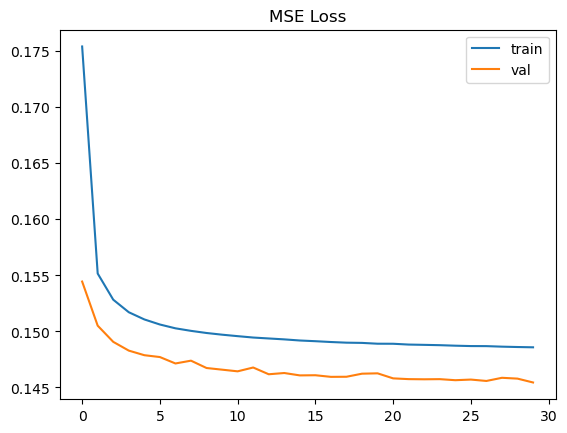

In [37]:
encoder, decoder = full_train(device, train_loader, val_loader)

In [39]:
score = classification_score(encoder, train_dataset, val_dataset, device)
assert score > 0.39
score

  0%|          | 0/5000 [00:00<?, ?it/s]

      Iter       Train Loss   Remaining Time 
         1           2.0684           17.23m
         2           1.8944           17.23m
         3           1.7640           17.00m
         4           1.6529           16.72m
         5           1.5513           16.37m
         6           1.4691           16.07m
         7           1.3924           15.73m
         8           1.3236           15.39m
         9           1.2617           15.04m
        10           1.2044           14.70m
        20           0.8113           11.06m
        30           0.5991            7.40m
        40           0.4636            3.71m
        50           0.3699            0.00s


  0%|          | 0/10000 [00:00<?, ?it/s]

0.434

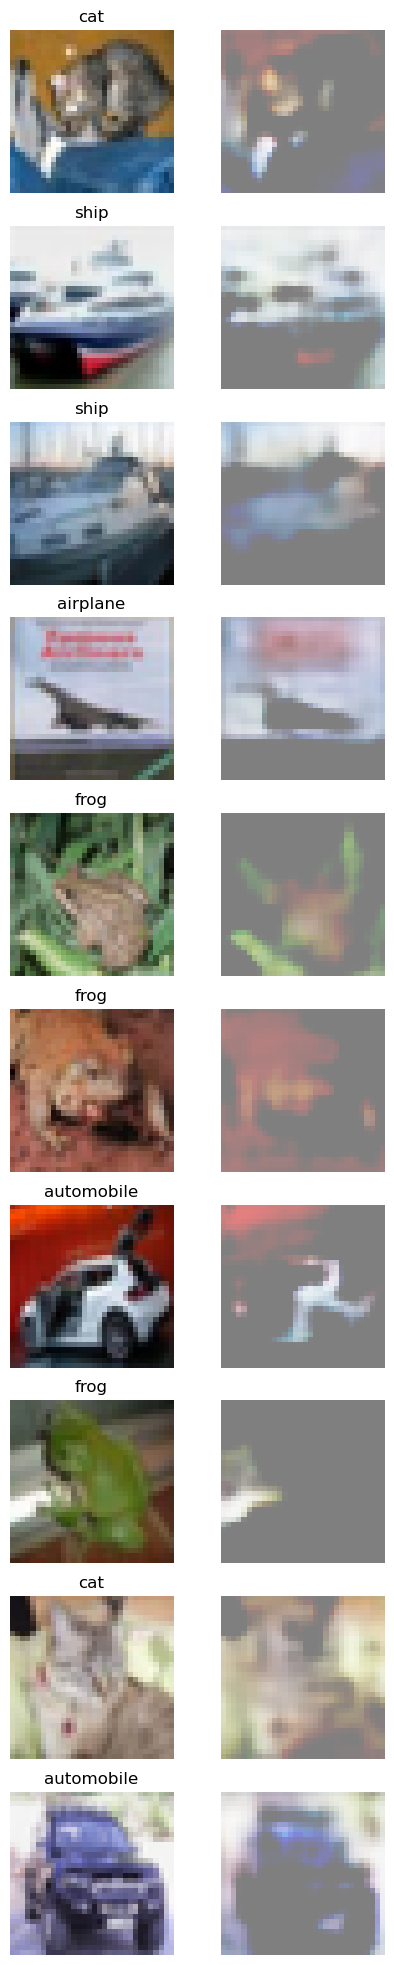

In [40]:
encoder.eval()
decoder.eval()
plt.figure(figsize=(5, 25))
for index, (image, label) in enumerate(val_loader):
    plt.subplot(10, 2, index*2+1)
    plt.imshow(denormalize_image(image)[0].permute(1, 2, 0))
    plt.axis('off')
    plt.title(text_labels[label])
    plt.subplot(10, 2, index*2+2)
    image = image.to(device)
    with torch.no_grad():
        emb = encoder(image)
        rec = decoder(emb).cpu()
    plt.imshow(denormalize_image(rec)[0].permute(1, 2, 0))
    plt.axis('off')
    if index == 9: break

### Задание 2. FID дистанция между классами CIFAR10 (3 балла)

В этой части хочется чтобы вы, используя bottleneck репрезентации от AE обученного в прошлой части посчитали FID дистанцию между различными классами CIFAR10 на **валидационной** выборке

За копию кода из сети будем снимать баллы

Напишите функцию get_representations, которая возвращает defaultdict, где ключ — это номер класса, значение — это список эмбеддингов, полученных из энкодера.

In [44]:
def get_representations(dataloader, encoder, device):
    representations = defaultdict(list)
     ### BEGIN SOLUTION
    encoder.eval()  
    with torch.no_grad():
        for images, labels in tqdm(dataloader, leave=False):

            images = images.to(device)
            labels = labels.to(device)
            
            embeddings = encoder(images)  #shape: (batch_size, 64, 4, 4)
            
            embeddings = embeddings.view(embeddings.size(0), -1)
            
            embeddings = embeddings[:, :256]  #shape: (batch_size, 256)
            
            embeddings = embeddings.cpu()
            labels = labels.cpu()
            
            for emb, label in zip(embeddings, labels):

                representations[label.item()].append(emb)
    return representations
    ### END SOLUTION

In [46]:
representations = get_representations(val_loader, encoder, device)
assert len(representations) == 10
assert len(representations[0]) == 1000
assert type(representations[0][0]) == torch.Tensor
assert representations[0][0].shape == (256, )

  0%|          | 0/10000 [00:00<?, ?it/s]

Напишите функцию расчета FID
$$\text{FID}=\left\|\mu_{r}-\mu_{g}\right\|^{2}+T_{r}\left(\Sigma_{r}+\Sigma_{g}-2\left(\Sigma_{r} \Sigma_{g}\right)^{1 / 2}\right)$$

In [49]:
from scipy.linalg import sqrtm
def calculate_fid(repr1, repr2):
    ### BEGIN SOLUTION

    def to_numpy(reprs):
        if isinstance(reprs, list):
            reprs = np.array([emb.detach().cpu().numpy() if isinstance(emb, torch.Tensor) else emb for emb in reprs])
        elif isinstance(reprs, torch.Tensor):
            reprs = reprs.detach().cpu().numpy()
        elif isinstance(reprs, np.ndarray):
            pass 
        else:
            raise ValueError("Unsupported data type for representations")
        return reprs

    repr1 = to_numpy(repr1)
    repr2 = to_numpy(repr2)

    mu1 = np.mean(repr1, axis=0)
    mu2 = np.mean(repr2, axis=0)

    sigma1 = np.cov(repr1, rowvar=False)
    sigma2 = np.cov(repr2, rowvar=False)

    diff = mu1 - mu2
    diff_squared = diff.dot(diff)

    covmean = sqrtm(sigma1.dot(sigma2))

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    trace_term = np.trace(sigma1 + sigma2 - 2 * covmean)

    fid = diff_squared + trace_term
    return fid
    ### END SOLUTION

In [50]:
heatmap = np.zeros((10, 10))
for label_from in trange(10):
    for label_to in range(10):
        fid = calculate_fid(
            torch.stack(representations[label_from], dim=0).cpu().numpy(),
            torch.stack(representations[label_to], dim=0).cpu().numpy()
        )
        heatmap[label_from, label_to] = fid
assert heatmap.shape == (10, 10)
assert np.all(heatmap + 1e-5 > 0)
airplane_ship = heatmap[0, 8]
airplane_frog = heatmap[0, 6]
truck_automobile = heatmap[9, 1]
truck_dog = heatmap[9, 5]
assert airplane_ship < airplane_frog
assert truck_automobile < truck_dog

  0%|          | 0/10 [00:00<?, ?it/s]

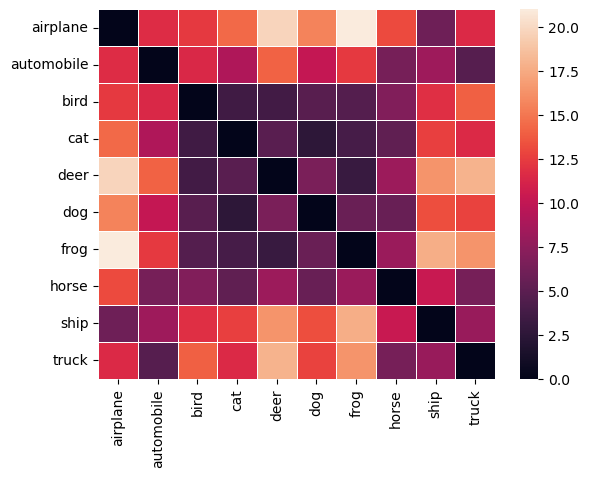

In [51]:
sns.heatmap(
    heatmap, 
    linewidth=0.5, 
    xticklabels=text_labels, 
    yticklabels=text_labels
)
plt.show()

## Задание 3 (3 балла)

Выберите ваш любимый датасет с кошками и собаками и посчитайте FID между двумя классами на новых данных, используя репрезентацию с уже обученного AE

хинт: если любимого датасета с кошками и собаками нет, можно вырезать эти классы из имажнета

хинт: если вам оооочень не нравятся кошки и собаки, то можете выбрать другие два противоположных класса

In [57]:
transform = transforms.Compose([
    transforms.ToTensor(),
])


test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

class_to_idx = {'cat': 3, 'dog': 5}
cat_idx = class_to_idx['cat']
dog_idx = class_to_idx['dog']

cat_indices = [i for i, (_, label) in enumerate(test_dataset) if label == cat_idx]
dog_indices = [i for i, (_, label) in enumerate(test_dataset) if label == dog_idx]

# Create subsets for 'cat' and 'dog' classes
cat_subset = Subset(test_dataset, cat_indices)
dog_subset = Subset(test_dataset, dog_indices)

# Create DataLoaders for 'cat' and 'dog' subsets
cat_loader = DataLoader(cat_subset, batch_size=64, shuffle=False)
dog_loader = DataLoader(dog_subset, batch_size=64, shuffle=False)

# Step 5: Define the function to get representations
def get_representations(dataloader, encoder, device):
    representations = []
    encoder.eval()  # Set encoder to evaluation mode
    with torch.no_grad():
        for images, _ in tqdm(dataloader, leave=False):
            images = images.to(device)
            embeddings = encoder(images)  # Get embeddings
            embeddings = embeddings.view(embeddings.size(0), -1)  # Flatten if necessary
            embeddings = embeddings[:, :256]  # Ensure embeddings are of size 256
            representations.extend(embeddings.cpu().numpy())
    return np.array(representations)

# Step 6: Load the trained encoder
# Assume encoder is already defined and trained
# If not loaded, you can load the state_dict
# encoder = Encoder().to(device)
# encoder.load_state_dict(torch.load('encoder_weights.pth', map_location=device))

# Step 7: Get representations for 'cat' and 'dog' classes
cat_reprs = get_representations(cat_loader, encoder, device)
dog_reprs = get_representations(dog_loader, encoder, device)

# Step 8: Compute the FID score
fid_score = calculate_fid(cat_reprs, dog_reprs)
print(f"FID score between 'cat' and 'dog' classes: {fid_score}")

Files already downloaded and verified


  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

FID score between 'cat' and 'dog' classes: 1.133906662020844


## Задание 4 (1 балл)

Вы отлично поработали и, скорее всего, в процессе выполнения этих задач у вас появились идеи о том, как еще можно решать подобные проблемы. 

Здесь вы можете описать способы которые вам хотелось бы попробовать если бы у вас было больше времени, или показать статьи которые вы читали, которые решают такие задачи.

Дополнительно, необходимо приложить сюда какой-нибудь смешной мем про генеративные модели за последние два года. Если мем будет не смешным, то баллы придется снять.

In [ ]:
# YOUR CODE HERE